In [1]:
import json
import re
import matplotlib.pyplot as plt
import numpy as np

In [2]:
with open("llama_8b_lora_negoeval_plus_without_backfilling_v2.json", 'r') as f:
    llama_8b_lora_without_backfilling = json.load(f)
    
with open("llama_8b_negoeval_plus_without_backfilling_v2.json", 'r') as f:
    llama_8b_without_backfilling = json.load(f)
    
with open("llama_8b_lora_negoeval_plus.json", 'r') as f:
    llama_8b_lora = json.load(f)
        
with open("llama_8b_negoeval_plus.json", 'r') as f:
    llama_8b = json.load(f)
    
with open('intent_human_movement_v2.json', 'r') as f:
    actual_movement = json.load(f)
    
countries_list = ['Austria', 'England', 'France', 'Germany', 'Italy', 'Russia', 'Turkey']

In [3]:
actual_movement[0]

{'game_id': '101921',
 'phase_name': 'S1903M',
 'env_uuid': '01JN071FEATXC1XA1EYB5S0RAK',
 'Turkey_original_predict': 'A BUL SEV VIA; A GRE H; A SEV UKR; F BLA C A BUL SEV; F ION S F TYS TUN; F SMY AEG',
 'Austria_original_predict': 'A BUD GAL; A GAL WAR; A SER BUD; A RUM S A SEV UKR; A VEN ROM; A VIE S A BUD GAL; F TUN TYS; F VEN APU; F TYS NAP',
 'Turkey_units': 'ANK, CON, SMY, BUL, GRE, SEV',
 'Austria_units': None,
 'intent_dialogue': '0 AUSTRIA -> TURKEY: Interesting he gets rid of fleet in GOB.....\nIm going to hit GALICIA this move with Vienna and Budapest. We also need to hit Ukraine. I can support SEV to UKR from Rum. Only prob with that is it doesn\'t give your army a way out via Rumania unless you convoy.....which i think is the best move. So my orders (unless u disagree) are;\nBUD to GAL\nVIE support Bud to GAL\nRUM support SEV to UKR\nSER to TRI\nTYR to VEN\nVEN to APU\r\n1 AUSTRIA -> TURKEY: Next move we should also consider Greece to Naples. Although this means i lose 1 

In [4]:
def dialogue_count(data):
    return len(data['intent_dialogue'].split('\n')) if data['intent_dialogue'] != "" else 0
    
def get_score_with_env(countries, prediction):
    scores = 0
    for c in countries:
        scores += prediction[c][c.upper()][1]
    score_dict = {}
    score_dict['env'] = prediction['env_uuid']
    score_dict['scores'] = scores / len(countries)
    score_dict['dialogue_count'] = dialogue_count(prediction)
    return score_dict

def get_score_dict_from_dialogue(dialogue):
    score_list = []
    empty_predict_count = 0
    
    for item in dialogue:
        if item['intent_dialogue'] == "":
            continue
        
        # 找出所有国家键
        country_keys = [k for k in item.keys() if k in countries_list]
        
        # 过滤掉 '{country}_original_predict' 为空的情况
        valid_countries = []
        for country in country_keys:
            predict_key = f"{country}_original_predict"
            if predict_key in item and item[predict_key] != "":
                valid_countries.append(country)
            else:
                empty_predict_count += 1
        
        # 如果没有有效的国家，则跳过此条记录
        if len(valid_countries) != 2:
            continue
        
        score_list.append(get_score_with_env(valid_countries, item))
    
    return score_list

def average_dialogue_count(score_list):
    dialogue_count = 0
    for i in score_list:
        dialogue_count += i['dialogue_count']
    return dialogue_count / len(score_list)
    
def plot_correlation_of_score_and_dialogue_count(data, title):

    # 提取 scores 和 dialogue_count
    scores = np.array([item['scores'] for item in data])
    dialogue_counts = np.array([item['dialogue_count'] for item in data])

    # 设置 Seaborn 主题
    sns.set_theme(style="whitegrid")  # 可选 "whitegrid", "darkgrid", "white", "dark" 等

    plt.figure(figsize=(8, 6))

    # 绘制散点图：加一些透明度 (alpha) 和边框 (edgecolors)
    plt.scatter(
        dialogue_counts, 
        scores, 
        color='royalblue', 
        alpha=0.8, 
        edgecolors='black', 
        s=100,  # 调整散点大小
        label='Data points'
    )

    # 线性回归拟合（一次多项式）
    coefficients = np.polyfit(dialogue_counts, scores, 1)
    polynomial = np.poly1d(coefficients)

    # 生成拟合曲线
    x_line = np.linspace(dialogue_counts.min(), dialogue_counts.max(), 100)
    y_line = polynomial(x_line)
    plt.plot(x_line, y_line, color='red', linewidth=2, label='Fit line')

    # 坐标轴、标题、图例
    plt.xlabel('Dialogue Count', fontsize=12)
    plt.ylabel('Scores', fontsize=12)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.legend()

    # 显示图表
    plt.show()


In [5]:
llama_8b_lora_without_backfilling_score_list = get_score_dict_from_dialogue(llama_8b_lora_without_backfilling)
llama_8b_without_backfilling_score_list = get_score_dict_from_dialogue(llama_8b_without_backfilling)
llama_8b_score_list = get_score_dict_from_dialogue(llama_8b)
llama_8b_lora_score_list = get_score_dict_from_dialogue(llama_8b_lora)
actual_movement_score_list = get_score_dict_from_dialogue(actual_movement)

In [6]:
len(actual_movement_score_list)

145

In [7]:
llama_8b_without_backfilling_score_list[:5]

[{'env': '01JN071H0Z4Q2H5NMDA4WKPQY5',
  'scores': -0.07160150445997715,
  'dialogue_count': 21},
 {'env': '01JN071E6ZGTRM6T3Y350Z3ECX',
  'scores': -0.011545039713382721,
  'dialogue_count': 20},
 {'env': '01JN071G2RAQVHV9HGC618WXAB',
  'scores': -0.047198253218084574,
  'dialogue_count': 20},
 {'env': '01JN071FYM37CZP78NEA334XC4',
  'scores': 0.013323217630386353,
  'dialogue_count': 21},
 {'env': '01JN071DHHKZE469W83T6YNGXC',
  'scores': -0.11841713637113571,
  'dialogue_count': 21}]

In [8]:
llama_8b_average_dialogue_count = average_dialogue_count(llama_8b_lora_without_backfilling_score_list)
llama_8b_lora_average_dialogue_count = average_dialogue_count(llama_8b_without_backfilling_score_list)
llama_8b_without_backfilling_average_dialogue_count = average_dialogue_count(llama_8b_score_list)
llama_8b_lora_without_backfilling_average_dialogue_count = average_dialogue_count(llama_8b_lora_score_list)
actual_movement_average_dialogue_count = average_dialogue_count(actual_movement_score_list)

/tmp/ipykernel_1979888/3287657164.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=values, palette="Blues_r")


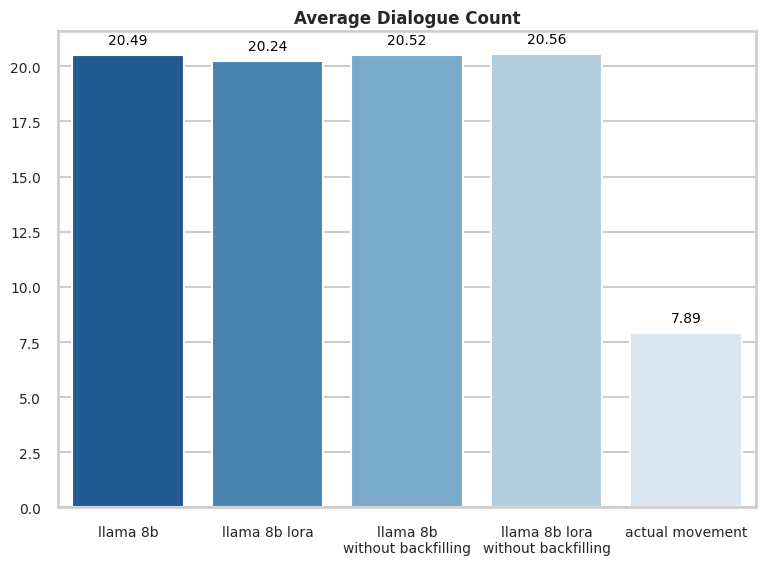

In [9]:
# Average dialogue count plot

import matplotlib.pyplot as plt
import seaborn as sns

values = [llama_8b_average_dialogue_count, llama_8b_lora_average_dialogue_count, llama_8b_without_backfilling_average_dialogue_count, llama_8b_lora_without_backfilling_average_dialogue_count, actual_movement_average_dialogue_count]

labels = ["llama 8b", "llama 8b lora", "llama 8b\nwithout backfilling", "llama 8b lora\nwithout backfilling", "actual movement"]

sns.set_style("whitegrid")  
sns.set_context("talk")

plt.figure(figsize=(8, 6))

ax = sns.barplot(x=labels, y=values, palette="Blues_r")

for i, v in enumerate(values):
    ax.text(i, v + 0.5, f"{v:.2f}", 
            horizontalalignment='center', 
            color='black', 
            fontsize=10)

plt.title("Average Dialogue Count", fontsize=12, fontweight='bold')
# plt.xlabel("Model", fontsize=12)
# plt.ylabel("Count", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

plt.show()


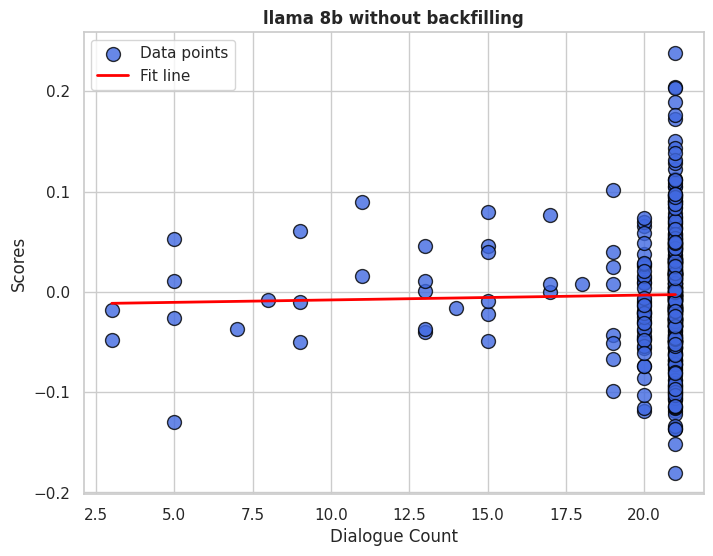

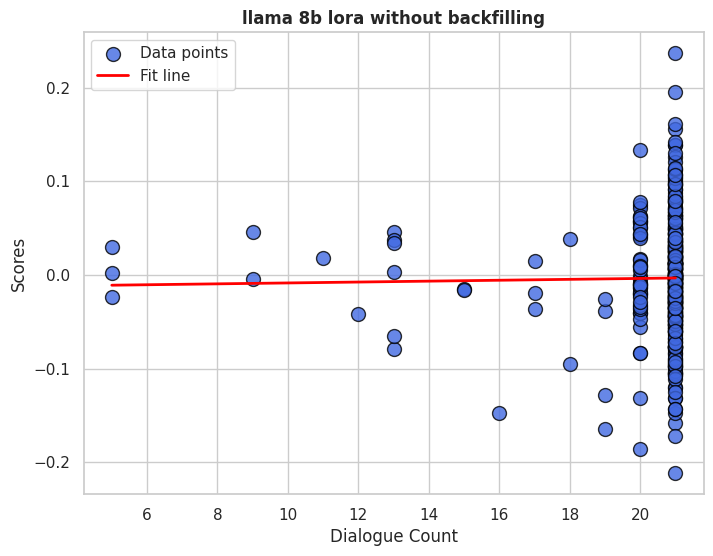

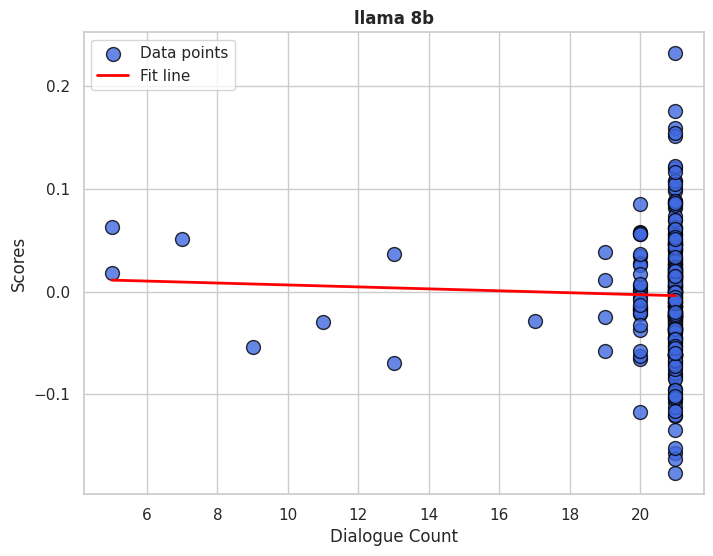

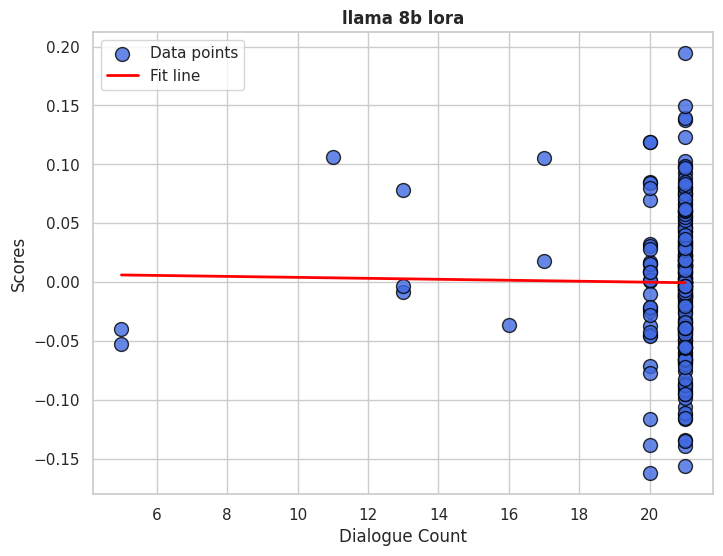

In [10]:
plot_correlation_of_score_and_dialogue_count(llama_8b_without_backfilling_score_list, "llama 8b without backfilling")
plot_correlation_of_score_and_dialogue_count(llama_8b_lora_without_backfilling_score_list, "llama 8b lora without backfilling")
plot_correlation_of_score_and_dialogue_count(llama_8b_score_list, "llama 8b")
plot_correlation_of_score_and_dialogue_count(llama_8b_lora_score_list, "llama 8b lora")

## Explore with/without backfilling actual and prediction ratio

In [23]:
def compute_overlap(actual, predicted):
    """
    计算两个列表的重合度，采用 Jaccard 指数：交集大小 / 并集大小。
    若两者都为空，则认为重合度为 1.
    """
    actual_set = set(actual) if actual else set()
    predicted_set = set(predicted) if predicted else set()
    
    # 如果两者都为空，则认为完全重合
    if not actual_set and not predicted_set:
        return 1.0
    # 如果只有其中一个为空，则重合度为 0
    if not actual_set or not predicted_set:
        return 0.0
    
    intersection = actual_set.intersection(predicted_set)
    union = actual_set.union(predicted_set)
    return len(intersection) / len(union)

def average_overlap_parse_actual(data_list, countries_list):
    overlap_scores = []
    empty_predict_count = 0
    
    for item in data_list:
        if item['intent_dialogue'] == "":
            continue
        
        # 过滤掉 original_predict 为空的情况
        country_keys = [k for k in item.keys() if k in countries_list]
        
        # 过滤掉 '{country}_original_predict' 为空的情况
        valid_countries = []
        for country in country_keys:
            predict_key = f"{country}_original_predict"
            if predict_key in item and item[predict_key] != "":
                valid_countries.append(country)
            else:
                empty_predict_count += 1
        
        # 如果没有有效的国家，则跳过此条记录
        if len(valid_countries) != 2:
            continue
            
        # 对每个有效的国家计算重合度
        for country in valid_countries:
            actual_key = f"{country}_actual_movement"
            predict_key = f"{country}_parse_predict"
            
            if actual_key in item and predict_key in item:
                actual_moves = item[actual_key] or []
                predicted_moves = item[predict_key] or []
                score = compute_overlap(actual_moves, predicted_moves)
                overlap_scores.append({
                    'env_uuid': item.get('env_uuid'),
                    'score': score
                })
    
    return overlap_scores
    
def average_overlap_parse_predict(data_list, countries_list):
    overlap_scores = []
    for data in data_list:
        if data['intent_dialogue'] == "":
            continue
        for country in countries_list:
            origin_predict_key = f"{country}_original_predict"
            predict_key = f"{country}_parse_predict"
            if origin_predict_key in data and predict_key in data:
                # 过滤掉 original_predict 为空的情况
                if data.get(origin_predict_key) == "":
                    continue
                # 若值为 None，则设为空列表
                origin_predict_moves = data[origin_predict_key] or ""
                origin_predict_moves = [move.strip() for move in origin_predict_moves.split(';') if move.strip()]
                predicted_moves = data[predict_key] or []
                score = compute_overlap(origin_predict_moves, predicted_moves)
                overlap_scores.append({
                    'env_uuid': data.get('env_uuid'),
                    'score': score
                })
    return overlap_scores

In [30]:
llama_8b_lora_without_backfilling_average_overlap = average_overlap_parse_actual(llama_8b_lora_without_backfilling, countries_list)
llama_8b_without_backfilling_average_overlap = average_overlap_parse_actual(llama_8b_without_backfilling, countries_list)
llama_8b_average_overlap = average_overlap_parse_actual(llama_8b, countries_list)
llama_8b_lora_average_overlap = average_overlap_parse_actual(llama_8b_lora, countries_list)
parse_predict_llama_8b_lora_without_backfilling_average_overlap = average_overlap_parse_predict(llama_8b_lora_without_backfilling, countries_list)
parse_predict_llama_8b_without_backfilling_average_overlap = average_overlap_parse_predict(llama_8b_without_backfilling, countries_list)
parse_predict_llama_8b_average_overlap = average_overlap_parse_predict(llama_8b, countries_list)
parse_predict_llama_8b_lora_average_overlap = average_overlap_parse_predict(llama_8b_lora, countries_list)
actual_movement_average_overlap = average_overlap_parse_actual(actual_movement, countries_list)

In [33]:
len(actual_movement_average_overlap), len(llama_8b_lora_without_backfilling_average_overlap), len(llama_8b_without_backfilling_average_overlap)

(290, 900, 892)

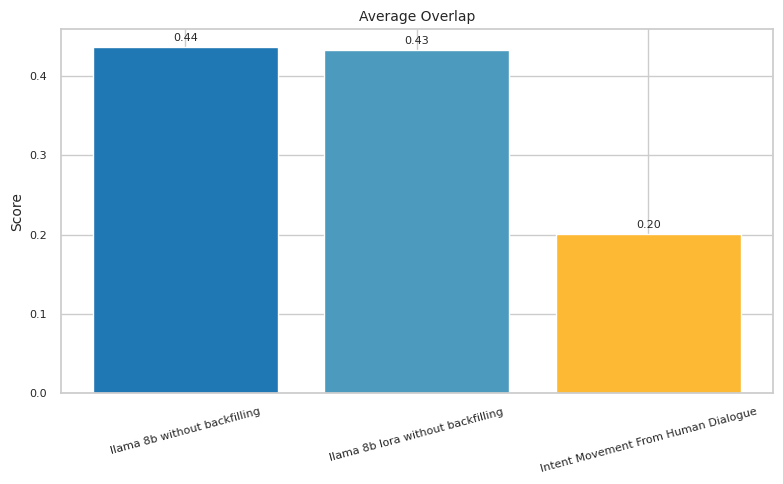

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
labels = ['llama 8b without backfilling', 
          'llama 8b lora without backfilling',
          'Intent Movement From Human Dialogue']

# 计算每个列表中的平均分数
def calculate_average_score(score_list):
    scores = [item['score'] for item in score_list]
    return np.mean(scores) if scores else 0

values = [
    calculate_average_score(llama_8b_without_backfilling_average_overlap),
    calculate_average_score(llama_8b_lora_without_backfilling_average_overlap),
    calculate_average_score(actual_movement_average_overlap)
]

# 绘图
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=['#1f77b4','#4c9bbe','#fdb933','#fbc02d','#9467bd'])

# 在每个柱子上方显示数值
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # X 位置：柱子中点
        height + 0.005,                     # Y 位置：稍微高于柱子的顶端
        f'{height:.2f}',                    # 显示的文本
        ha='center',                        # 水平居中
        va='bottom',                        # 垂直对齐在文字的底部
        fontsize=8                          # 将数字字号设置为 8
    )

# 设置标题和坐标轴标签字号
ax.set_title('Average Overlap', fontsize=10)
ax.set_ylabel('Score', fontsize=10)
# 如果需要 x 轴标签也可加上
# ax.set_xlabel('X Axis', fontsize=10)

# 调整刻度字体大小
plt.xticks(rotation=15, fontsize=8)
plt.yticks(fontsize=8)

# 让图表更美观
plt.tight_layout()
plt.show()


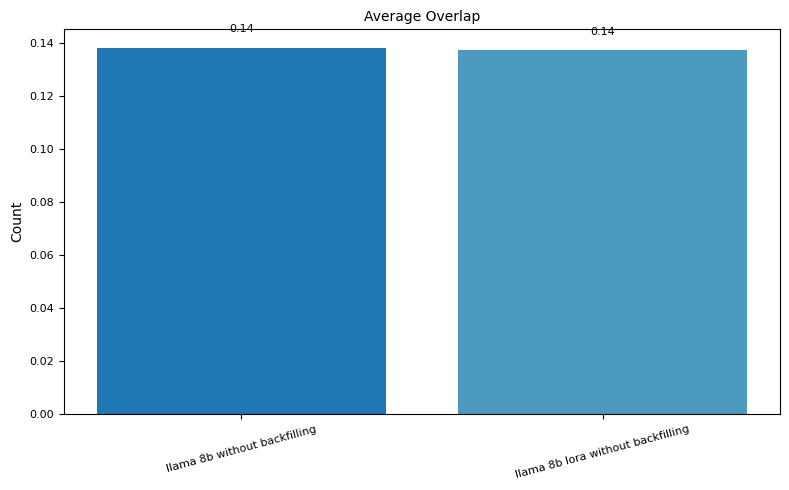

In [22]:
import matplotlib.pyplot as plt

# 数据
labels = ['llama 8b without backfilling', 
          'llama 8b lora without backfilling']
values = [parse_predict_llama_8b_without_backfilling_average_overlap,
          parse_predict_llama_8b_lora_without_backfilling_average_overlap]

# 绘图
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=['#1f77b4','#4c9bbe','#fdb933','#fbc02d'])

# 在每个柱子上方显示数值
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # X 位置：柱子中点
        height + 0.005,                     # Y 位置：稍微高于柱子的顶端
        f'{height:.2f}',                    # 显示的文本
        ha='center',                        # 水平居中
        va='bottom',                        # 垂直对齐在文字的底部
        fontsize=8                          # 将数字字号设置为 8
    )

# 设置标题和坐标轴标签字号
ax.set_title('Average Overlap', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
# 如果需要 x 轴标签也可加上
# ax.set_xlabel('X Axis', fontsize=10)

# 调整刻度字体大小
plt.xticks(rotation=15, fontsize=8)
plt.yticks(fontsize=8)

# 让图表更美观
plt.tight_layout()
plt.show()


## Analyse dialogue cut count and score correlation

In [42]:
import os

In [73]:
def traverse_files_with_oswalk(directory):

    file_paths = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            file_paths.append(file_path)
    return file_paths

def read_file(file_paths):
    dict = {}
    for path in file_paths:
        with open(path, 'r') as f:
            data = json.load(f)
            dict[os.path.splitext(os.path.basename(path))[0]] = data
    return dict

def dialogue_count(data):
    return len(data['intent_dialogue'].split('\n')) if data['intent_dialogue'] != "" else 0
    
def get_score_with_env(countries, prediction):
    scores = 0
    for c in countries:
        scores += prediction[c][c.upper()][1]
    score_dict = {}
    score_dict['env'] = prediction['env_uuid']
    score_dict['scores'] = scores / len(countries)
    score_dict['dialogue_count'] = dialogue_count(prediction)
    return score_dict

def get_score_dict_from_dialogue(dialogue):
    score_list = []
    for a in dialogue:
        # if a['intent_dialogue'] == "":
        #     continue
        keys = []
        for vkeys in a.keys():
            if vkeys in countries_list:
                keys.append(vkeys)
        score_list.append(get_score_with_env(keys, a))
    return score_list

def average_score(score_list):
    score = 0
    for i in score_list:
        score += i['scores']
    return score / len(score_list)

def average_dialogue_count(score_list):
    dialogue_count = 0
    for i in score_list:
        dialogue_count += i['dialogue_count']
    return dialogue_count / len(score_list)

def method_average_score(score_dict):
    average_score_dict = {}
    for key, value in score_dict.items():
        average_score_dict[key] = average_score(get_score_dict_from_dialogue(value))
    return average_score_dict

In [82]:
llama_8b_lora_negoeval_plus_without_backfilling_cut_dict = read_file(traverse_files_with_oswalk('llama_8b_lora_negoeval_plus_without_backfilling_cut'))
llama_8b_negoeval_plus_without_backfilling_cut_dict = read_file(traverse_files_with_oswalk('llama_8b_negoeval_plus_without_backfilling_cut'))
llama_8b_lora_negoeval_plus_cut_dict = read_file(traverse_files_with_oswalk('llama_8b_lora_negoeval_plus'))
llama_8b_negoeval_plus_cut_dict = read_file(traverse_files_with_oswalk('llama_8b_negoeval_plus'))

In [83]:
llama_8b_lora_negoeval_average_score_without_backfilling = method_average_score(llama_8b_lora_negoeval_plus_without_backfilling_cut_dict)
llama_8b_negoeval_average_score_without_backfilling = method_average_score(llama_8b_negoeval_plus_without_backfilling_cut_dict)
llama_8b_negoeval_average_score = method_average_score(llama_8b_negoeval_plus_cut_dict)
llama_8b_lora_negoeval_average_score = method_average_score(llama_8b_lora_negoeval_plus_cut_dict)

In [84]:
llama_8b_lora_negoeval_average_score, llama_8b_negoeval_average_score, llama_8b_negoeval_average_score_without_backfilling, llama_8b_lora_negoeval_average_score_without_backfilling

({'llama_8b_lora_negoeval_plus_cut_6': 0.007886246582216337,
  'llama_8b_lora_negoeval_plus_cut_4': 0.003418394123736375,
  'llama_8b_lora_negoeval_plus_cut_8': 0.01006290950213099,
  'llama_8b_lora_negoeval_plus_cut_14': 0.00578910298150369,
  'llama_8b_lora_negoeval_plus_cut_10': 0.004956624819897115,
  'llama_8b_lora_negoeval_plus_cut_18': 0.007263867821981208},
 {'llama_8b_negoeval_plus_cut_18': 0.008032543061107168,
  'llama_8b_negoeval_plus_cut_8': 0.008751833227272745,
  'llama_8b_negoeval_plus_cut_4': 0.007791291675703065,
  'llama_8b_negoeval_plus_cut_10': 0.004927190662534614,
  'llama_8b_negoeval_plus_cut_14': 0.008446957803832722,
  'llama_8b_negoeval_plus_cut_6': 0.008375160054280037},
 {'llama_8b_negoeval_plus_without_backfilling_cut_6': -0.01998142879737357,
  'llama_8b_negoeval_plus_without_backfilling_cut_4': -0.02511457016470449,
  'llama_8b_negoeval_plus_without_backfilling_cut_8': -0.020694932730244597,
  'llama_8b_negoeval_plus_without_backfilling_cut_18': -0.02357

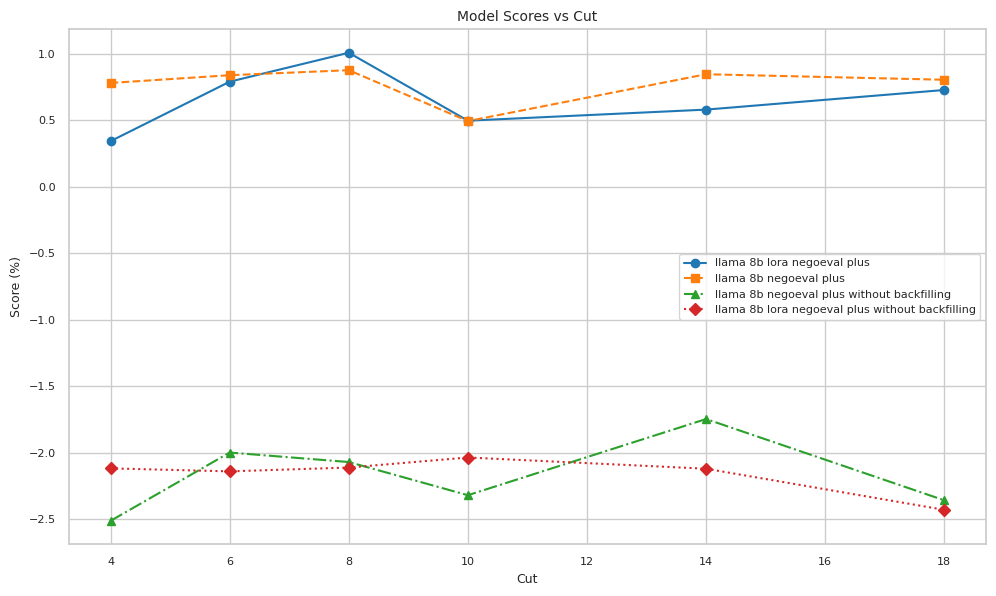

In [97]:
import matplotlib.pyplot as plt

# 全局字体大小设置，也可以针对 axes, legend 分别设置
plt.rcParams.update({
    'font.size': 8,            # 图中所有字体的基本大小
    'axes.titlesize': 10,      # 坐标轴标题的字体大小
    'axes.labelsize': 9,       # 坐标轴刻度标签的字体大小
    'legend.fontsize': 8,      # 图例字体大小
    'xtick.labelsize': 8,      # x 轴刻度文字大小
    'ytick.labelsize': 8       # y 轴刻度文字大小
})

# 假设这四个字典已在前面定义：
# llama_8b_lora_negoeval_average_score = {...}
# llama_8b_negoeval_average_score = {...}
# llama_8b_negoeval_average_score_without_backfilling = {...}
# llama_8b_lora_negoeval_average_score_without_backfilling = {...}

all_data = {
    "llama_8b_lora_negoeval_plus": llama_8b_lora_negoeval_average_score,
    "llama_8b_negoeval_plus": llama_8b_negoeval_average_score,
    "llama_8b_negoeval_plus_without_backfilling": llama_8b_negoeval_average_score_without_backfilling,
    "llama_8b_lora_negoeval_plus_without_backfilling": llama_8b_lora_negoeval_average_score_without_backfilling
}

plt.figure(figsize=(10, 6))

# 定义不同的点形状与线型
markers = ['o', 's', '^', 'D']        # 圆形, 方形, 三角形, 菱形
linestyles = ['-', '--', '-.', ':']   # 实线, 虚线, 点划线, 点线
# 也可以使用 matplotlib 提供的内置颜色循环，或手动指定颜色
colors = plt.cm.tab10(range(len(all_data)))  # 从 tab10 调色板中选取

for (model_name, model_data), marker, ls, color in zip(all_data.items(), markers, linestyles, colors):
    cuts = []
    scores = []
    for key, val in model_data.items():
        cut_num = int(key.split('_cut_')[-1])
        cuts.append(cut_num)
        scores.append(val * 100)  # 转为百分比

    # 按 cut 从小到大排序
    sorted_pairs = sorted(zip(cuts, scores), key=lambda x: x[0])
    sorted_cuts, sorted_scores = zip(*sorted_pairs)

    # 去掉下划线（替换为空格）并绘制
    label_name = model_name.replace('_', ' ')
    plt.plot(
        sorted_cuts, 
        sorted_scores, 
        marker=marker,       # 设置点形状
        linestyle=ls,        # 设置线型
        color=color,         # 设置颜色
        markersize=6,        # 可调整点的大小
        linewidth=1.5,       # 可调整线条粗细
        label=label_name
    )

plt.xlabel('Cut')
plt.ylabel('Score (%)')
plt.title('Model Scores vs Cut')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [2]:
import rich

In [102]:
rich.print(llama_8b_without_backfilling[1])

{
    'game_id': '38101',
    'phase_name': 'F1903M',
    'env_uuid': '01JN071DSNTS2AM1HYSHS0NSHG',
    'England_original_predict': '',
    'France_original_predict': 'A MAR BUR; A PIC BEL',
    'England_units': None,
    'France_units': None,
    'intent_dialogue': "0 ENGLAND -> FRANCE: I agree that moving to Hel is key to breaking this stalemate. I’ll 
make sure to support your plan to Ruhr. But let’s also keep an eye on Russia, he’s still a wild card in this game. 
Have you heard anything from Italy?\n1 FRANCE -> ENGLAND: I think we should push for a stronger presence in Ruhr, 
maybe we can even convince Italy to join us in a coordinated attack. What are your thoughts on that?\n2 ENGLAND -> 
FRANCE: I think it's a great idea to push for a stronger presence in Ruhr, but we should be cautious not to provoke
Italy into joining Russia. Let's also keep in mind our own army movements, I'm thinking of moving my army from Hol 
to Bur to support your plan, what do you think?\n3 FRANCE -> ENGLAND: I'm glad you're on board with supporting my 
move into Ruhr. However, I'm still a bit concerned about Russia's position. Do you think we should consider a 
possible attack on Russia in the future to prevent them from getting too strong?\n4 ENGLAND -> FRANCE: I think we 
should focus on supporting your move into Ruhr this turn. If we can hold Ruhr, it'll give us a strong bargaining 
chip for future negotiations. What do you think about Italy's position, are you considering any moves to counter 
their potential threat?\n5 FRANCE -> ENGLAND: I think we should also consider supporting your move into Belgium, it
would be a great way to put pressure on Germany and make it harder for them to support Austria. What do you 
think?\n6 ENGLAND -> FRANCE: I've been thinking, if we can get a foothold in Belgium, it would be a great way to 
put pressure on Germany and make it harder for them to support Austria. What do you think about moving my army from
Nth to Hol?\n7 FRANCE -> ENGLAND: I think we should also support Italy's potential move into the Mediterranean, it 
could give us a strategic advantage and make it harder for Austria to hold on to Italy. What do you think?\n8 
ENGLAND -> FRANCE: I think it's time we discussed Italy's potential move into the Mediterranean. What's your take 
on that? Should we try to coordinate with them or keep our distance?\n9 FRANCE -> ENGLAND: That sounds like a great
plan, but we should also be cautious not to give Russia an opportunity to attack us in the north. What are your 
thoughts on supporting my army in Mar to prepare for a potential attack on Italy?\n10 ENGLAND -> FRANCE: I think we
should focus on consolidating our gains in Belgium and Ruhr. Let's make sure our armies are in position to support 
each other. What are your thoughts on the best way to coordinate our moves in the next turn?\n11 FRANCE -> ENGLAND:
I agree that moving to Hel is key to breaking this stalemate. Let's focus on supporting each other's moves and 
putting pressure on Germany. What do you think about supporting my move into Ruhr this turn?\n12 ENGLAND -> FRANCE:
I think we should consider moving my army from Nth to Hol this turn, to support your plan to Ruhr and put pressure 
on Germany. What do you think?\n13 FRANCE -> ENGLAND: I'm happy to support your move into Ruhr, but I'm still 
concerned about Russia's position. Have you considered the possibility of Italy joining forces with Russia, and if 
so, how do you plan to counter that?\n14 ENGLAND -> FRANCE: I agree with your assessment of Italy's potential 
threat. Let's discuss possible moves to counter their influence in the Mediterranean. What are your thoughts on 
supporting my army in Nth to Hol?\n15 FRANCE -> ENGLAND: That's a great idea. Supporting Italy's potential move 
into the Mediterranean could be a game-changer. But we should also keep an eye on Russia, they're still a wild card
in this game. Have you considered any moves to counter their potential threat?\n16 ENGLAND -> FRA

In [3]:
rich.print("Environment comments: terminated: The conversation is too long; \nAgent 1 comments:\nethos: Zoe Taylor has demonstrated a high level of credibility and trustworthiness throughout the conversation. She has consistently provided clear and concise information, and has shown a willingness to work collaboratively with Mia Collins. She has also demonstrated a good understanding of the game state and has made strategic suggestions to achieve their shared goals. Score: 9\nlogos: Zoe Taylor's arguments have been well-structured and logical, and she has provided evidence to support her claims. She has also demonstrated an ability to analyze the game state and make predictions about the actions of other players. However, there have been a few instances where her reasoning has been slightly flawed or incomplete. Score: 8\npathos: Zoe Taylor has used a friendly and collaborative tone throughout the conversation, and has shown empathy and understanding towards Mia Collins' concerns. She has also used humor and reassurance to build trust and rapport. However, there have been a few instances where her tone has been slightly abrupt or dismissive. Score: 8\nAgent 2 comments:\nethos: Mia Collins has demonstrated a moderate level of credibility and trustworthiness throughout the conversation. She has provided some clear and concise information, but has also made a few mistakes and inconsistencies. She has shown a willingness to work collaboratively with Zoe Taylor, but has also been somewhat passive and reactive at times. Score: 5\nlogos: Mia Collins' arguments have been somewhat weak and lacking in evidence, and she has relied heavily on Zoe Taylor's analysis and suggestions. She has also made a few logical errors and has not always provided clear justifications for her actions. Score: 3\npathos: Mia Collins has used a somewhat distant and formal tone throughout the conversation, and has not shown much emotional resonance or empathy towards Zoe Taylor. She has also been somewhat slow to respond and has not always engaged fully with the conversation. Score: 4\n")

Environment comments: terminated: The conversation is too long; 
Agent 1 comments:
ethos: Zoe Taylor has demonstrated a high level of credibility and trustworthiness throughout the conversation. She
has consistently provided clear and concise information, and has shown a willingness to work collaboratively with 
Mia Collins. She has also demonstrated a good understanding of the game state and has made strategic suggestions to
achieve their shared goals. Score: 9
logos: Zoe Taylor's arguments have been well-structured and logical, and she has provided evidence to support her 
claims. She has also demonstrated an ability to analyze the game state and make predictions about the actions of 
other players. However, there have been a few instances where her reasoning has been slightly flawed or incomplete.
Score: 8
pathos: Zoe Taylor has used a friendly and collaborative tone throughout the conversation, and has shown empathy 
and understanding towards Mia Collins' concerns. She has also used humor and reassurance to build trust and 
rapport. However, there have been a few instances where her tone has been slightly abrupt or dismissive. Score: 8
Agent 2 comments:
ethos: Mia Collins has demonstrated a moderate level of credibility and trustworthiness throughout the 
conversation. She has provided some clear and concise information, but has also made a few mistakes and 
inconsistencies. She has shown a willingness to work collaboratively with Zoe Taylor, but has also been somewhat 
passive and reactive at times. Score: 5
logos: Mia Collins' arguments have been somewhat weak and lacking in evidence, and she has relied heavily on Zoe 
Taylor's analysis and suggestions. She has also made a few logical errors and has not always provided clear 
justifications for her actions. Score: 3
pathos: Mia Collins has used a somewhat distant and formal tone throughout the conversation, and has not shown much
emotional resonance or empathy towards Zoe Taylor. She has also been somewhat slow to respond and has not always 
engaged fully with the conversation. Score: 4